## LSTM para previsão de preço de café

# 1. Preparação do ambiente

In [1]:
from IPython.display import display, HTML

display(HTML("<style>.container {width: 100% !important;}</style>"))

## 1.1. Importação de bibliotecas

In [2]:
import yfinance as yf
import torch

import matplotlib.pyplot as plt
import pandas as pd

## 1.2. Checagem de GPU

In [3]:
if torch.cuda.is_available():
    print("__CUDNN VERSION:", torch.backends.cudnn.version())
    print("Device Name:", torch.cuda.get_device_name(0))
    device = 'cuda'
else:
    print("CUDA is not available.")
    device = 'cpu'

print('Device:', device)

__CUDNN VERSION: 91900
Device Name: NVIDIA GeForce RTX 5070
Device: cuda


# 2. Base de dados

## 2.1. Baixar preços de café e dolar

In [4]:
raw = yf.download(
    ["KC=F", "BRL=X"],
    start="2012-01-01",
    end="2025-12-31",
    interval="1d"
)

raw

[*********************100%***********************]  2 of 2 completed


Price        Close                High                   Low              \
Ticker       BRL=X        KC=F   BRL=X        KC=F     BRL=X        KC=F   
Date                                                                       
2012-01-02  1.8623         NaN  1.8690         NaN  1.853500         NaN   
2012-01-03  1.8701  227.199997  1.8697  228.000000  1.829400  222.399994   
2012-01-04  1.8345  226.699997  1.8346  229.149994  1.813100  224.399994   
2012-01-05  1.8184  219.550003  1.8455  225.800003  1.819700  217.550003   
2012-01-06  1.8430  221.750000  1.8538  222.399994  1.833300  216.600006   
...            ...         ...     ...         ...       ...         ...   
2025-12-23  5.5900  346.950012  5.6168  352.399994  5.528969  345.600006   
2025-12-24  5.5185  345.149994  5.5227  348.649994  5.512667  343.049988   
2025-12-26  5.5195  350.250000  5.5650  350.700012  5.514800  344.299988   
2025-12-29  5.5425  352.149994  5.5841  354.299988  5.535520  347.049988   
2025-12-30  5.5691  350.200012  5.5777  359.299988  5.481326  349.500000   

Price         Open             Volume           
Ticker       BRL=X        KC=F  BRL=X     KC=F  
Date                                            
2012-01-02  1.8599         NaN    0.0      NaN  
2012-01-03  1.8577  226.850006    0.0  10692.0  
2012-01-04  1.8346  226.000000    0.0  10663.0  
2012-01-05  1.8197  225.449997    0.0  15059.0  
2012-01-06  1.8377  219.000000    0.0   9980.0  
...            ...         ...    ...      ...  
2025-12-23  5.5900  350.000000    0.0  11078.0  
2025-12-24  5.5205  348.100006    0.0      0.0  
2025-12-26  5.5148  345.799988    0.0   7348.0  
2025-12-29  5.5428  349.500000    0.0   9184.0  
2025-12-30  5.5721  350.549988    0.0  11564.0  

[3649 rows x 10 columns]

In [5]:
df_market = raw["Close"].copy()
df_market.columns.name = None
df_market

,BRL=X,KC=F
Date,,
2012-01-02,1.8623,NaN
2012-01-03,1.8701,227.199997
2012-01-04,1.8345,226.699997
2012-01-05,1.8184,219.550003
2012-01-06,1.8430,221.750000
...,...,...
2025-12-23,5.5900,346.950012
2025-12-24,5.5185,345.149994
2025-12-26,5.5195,350.250000


In [6]:
df_market = df_market.rename(columns={
    "KC=F":  "preco_cafe",
    "BRL=X": "cotacao_dolar",
})

df_market

,cotacao_dolar,preco_cafe
Date,,
2012-01-02,1.8623,NaN
2012-01-03,1.8701,227.199997
2012-01-04,1.8345,226.699997
2012-01-05,1.8184,219.550003
2012-01-06,1.8430,221.750000
...,...,...
2025-12-23,5.5900,346.950012
2025-12-24,5.5185,345.149994
2025-12-26,5.5195,350.250000


In [7]:
df_market.index = pd.to_datetime(df_market.index).tz_localize(None)
df_market.index.name = "date"
df_market = df_market[["preco_cafe", "cotacao_dolar"]].dropna(how="all")

df_market

,preco_cafe,cotacao_dolar
date,,
2012-01-02,NaN,1.8623
2012-01-03,227.199997,1.8701
2012-01-04,226.699997,1.8345
2012-01-05,219.550003,1.8184
2012-01-06,221.750000,1.8430
...,...,...
2025-12-23,346.950012,5.5900
2025-12-24,345.149994,5.5185
2025-12-26,350.250000,5.5195


## 2.2. Explorar base de dados

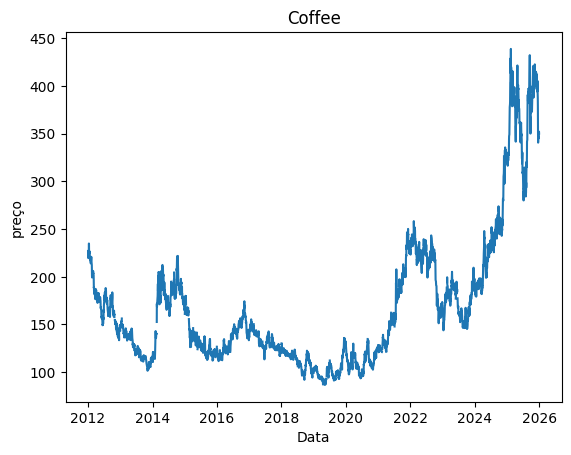

In [8]:
plt.plot(df_market['preco_cafe'])
plt.title('Coffee')
plt.xlabel("Data")
plt.ylabel('preço')
plt.show()

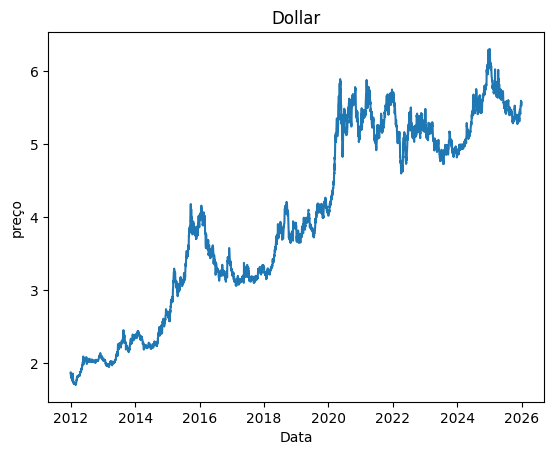

In [9]:
plt.plot(df_market['cotacao_dolar'])
plt.title('Dollar')
plt.xlabel("Data")
plt.ylabel('preço')
plt.show()

array([[<Axes: title={'center': 'preco_cafe'}>,
        <Axes: title={'center': 'cotacao_dolar'}>]], dtype=object)

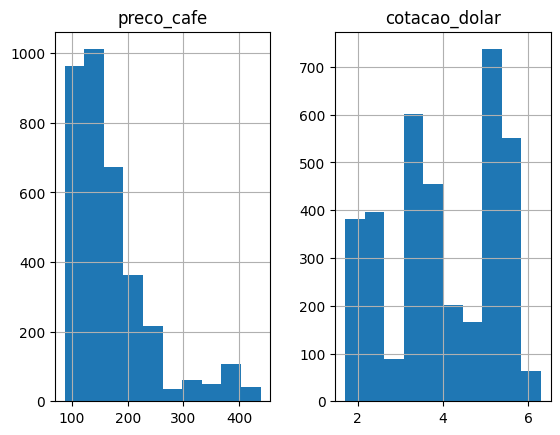

In [10]:
df_market.hist()

## 2.3. Checagem de valores nulos

In [11]:
missing_counts = df_market.isnull().sum()
print("Total de dados faltantes por atributo:")
print(missing_counts)

Total de dados faltantes por atributo:
preco_cafe       130
cotacao_dolar      6
dtype: int64


## 2.4. Juntar dataset de clima e café

In [12]:
df_weather = pd.read_csv('data/climate_imputed.csv', index_col=0)
df_weather = df_weather.reset_index()
df_weather = df_weather.rename(columns={"datetime": "date"})
df_weather["date"] = pd.to_datetime(df_weather["date"])

df_market_reset = df_market.reset_index()

df_weather

,date,chuva,temp,temp_max,temp_min,umidade
0,2012-01-01,27.2,20.016667,22.700,19.100,95.833333
1,2012-01-02,22.6,19.829167,23.900,17.800,92.916667
2,2012-01-03,0.4,21.462500,28.200,17.500,79.666667
3,2012-01-04,0.0,22.187500,29.300,15.900,67.416667
4,2012-01-05,0.0,22.341667,29.500,15.500,66.708333
...,...,...,...,...,...,...
5109,2025-12-27,0.0,21.540000,27.460,17.696,80.058000
5110,2025-12-28,0.0,21.468000,27.320,17.736,80.772000
5111,2025-12-29,0.0,21.478000,27.382,17.769,80.885000
5112,2025-12-30,0.0,21.519000,27.367,17.771,80.646000


In [19]:
df = df_market.reset_index().merge(
    df_weather.reset_index(),
    on="date",
    how="left"
)
df.dropna(subset=["date", 'preco_cafe', 'cotacao_dolar'], inplace=True)
df.drop('index', axis=1, inplace=True)
df.to_csv('data/coffee.csv', index=False)

df

,date,preco_cafe,cotacao_dolar,chuva,temp,temp_max,temp_min,umidade
1,2012-01-03,227.199997,1.8701,0.4,21.462500,28.200,17.500,79.666667
2,2012-01-04,226.699997,1.8345,0.0,22.187500,29.300,15.900,67.416667
3,2012-01-05,219.550003,1.8184,0.0,22.341667,29.500,15.500,66.708333
4,2012-01-06,221.750000,1.8430,25.8,20.600000,28.300,17.500,81.458333
5,2012-01-09,221.850006,1.8476,21.2,18.066667,22.500,16.100,90.458333
...,...,...,...,...,...,...,...,...
3644,2025-12-23,346.950012,5.5900,0.0,21.994000,28.027,17.813,77.394000
3645,2025-12-24,345.149994,5.5185,0.0,21.899000,27.962,17.711,77.869000
3646,2025-12-26,350.250000,5.5195,0.0,21.665000,27.602,17.667,79.039000
3647,2025-12-29,352.149994,5.5425,0.0,21.478000,27.382,17.769,80.885000
